# Machine learning model

## Setup

### Imports, global constants and functions

In [ ]:
import pandas as pd
import geopandas as gpd
import glob
import matplotlib.pyplot as plt
from shapely.geometry import box
from shapely.geometry import Polygon

In [812]:
BBOX_MAX_LAT = 39.492119
BBOX_MIN_LAT = 39.3653539
BBOX_MIN_LON = -0.343666
BBOX_MAX_LON = -0.213547

In [813]:
BBOX: Polygon = box(BBOX_MIN_LON, BBOX_MIN_LAT, BBOX_MAX_LON, BBOX_MAX_LAT)

In [814]:
def load_parquet(path_pattern: str, engine: str ='fastparquet') -> pd.DataFrame:
    """
    Loads parquet file(s).
    Supports glob patterns like "*.parquet.gzip".

    Args:
        path_pattern: File path or glob pattern.
        engine: Parquet engine.

    Returns:
        Single DataFrame, concatenated if multiple files.
    """

    files = glob.glob(path_pattern)
    if not files:
        raise FileNotFoundError(f"No files found matching: {path_pattern}")

    dfs = [pd.read_parquet(f, engine=engine) for f in files]
    df = pd.concat(dfs, ignore_index=True) if len(dfs) > 1 else dfs[0]
    print(f"Loaded {len(df):,} rows from {len(dfs)} files matching \"{path_pattern}\"")

    return df

In [815]:
def draw_bbox(coastline_gdf: gpd.GeoDataFrame, poly: Polygon) -> None:
    bbox_gdf = gpd.GeoDataFrame(geometry=[poly], crs="EPSG:4326") # Coordinat Reference System, WGS84 lat/long in degrees

    # Plot
    _, ax = plt.subplots(figsize=(6, 6))
    coastline_gdf.plot(ax=ax, color="darkgreen", edgecolor="black")
    bbox_gdf.boundary.plot(ax=ax, facecolor="red", edgecolor="black", alpha=0.75)

    # Add padding around bbox (200%)
    pad_lon = (BBOX_MAX_LON - BBOX_MIN_LON) * 4
    pad_lat = (BBOX_MAX_LAT - BBOX_MIN_LAT) * 4

    x_lims = (BBOX_MIN_LON - pad_lon, BBOX_MAX_LON + pad_lon)
    y_lims = (BBOX_MIN_LAT - pad_lat, BBOX_MAX_LAT + pad_lat)

    ax.set_xlim(x_lims)
    ax.set_ylim(y_lims)

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(f"Berth bounding box")
    ax.legend()
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

In [816]:
def plot_voyage_on_coastline(voyage_df: pd.DataFrame, coastline_gdf: gpd.GeoDataFrame, poly: Polygon, padding: float = 0.1) -> None:
    # Sort by timestamp
    voyage_df = voyage_df.sort_values(by="pos_timestamp", ascending=True, inplace=False)

    # Get voyage coord bounds
    min_lon, max_lon = voyage_df['longitude'].min(), voyage_df['longitude'].max()
    min_lat, max_lat = voyage_df['latitude'].min(), voyage_df['latitude'].max()

    # Calculate range (square window)
    lon_range = max_lon - min_lon
    lat_range = max_lat - min_lat
    full_range = max(lon_range, lat_range)

    pad = full_range * padding
    center_lon = (min_lon + max_lon) / 2
    center_lat = (min_lat + max_lat) / 2

    x_lims = (center_lon - full_range/2 - pad, center_lon + full_range/2 + pad)
    y_lims = (center_lat - full_range/2 - pad, center_lat + full_range/2 + pad)

    poly_gdf = gpd.GeoDataFrame(geometry=[poly], crs="EPSG:4326")

    # Single figure
    _, ax = plt.subplots(figsize=(12, 12))
    coastline_gdf.plot(ax=ax, color="darkgreen", edgecolor="black", label="Coastline")

    # Voyage
    ax.plot(
        voyage_df['longitude'], voyage_df['latitude'],
        marker='o', linestyle='-', color='blue', label="Voyage Trajectory", markersize=2, markeredgecolor="black"
    )

    # BBox on SAME axes
    poly_gdf.boundary.plot(ax=ax, facecolor="red", edgecolor="black", alpha=0.75, label="Bounding box")

    ax.set_xlim(x_lims)
    ax.set_ylim(y_lims)
    ax.set_aspect('equal')

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(f"Voyage: {voyage_df['voyage_id'].iloc[0]}")
    ax.legend()
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    print(
        f"Voyage: {voyage_df['voyage_id'].iloc[0]} "
        f"\nTotal traveled distance: {voyage_df['total_dist_km'].iloc[0].round(2)} km"
        f"\nDuration: {(voyage_df['duration'].iloc[0] / 3600).round(2)} hours"
        f"\nData points: {voyage_df.shape[0]}"
    )

In [817]:
def plot_all_voyages(df: pd.DataFrame, coastline_gdf: gpd.GeoDataFrame, poly: Polygon, padding: float = 0.1, max_voyages: int = 20) -> None:
    """Plot ALL unique voyages from dataframe."""
    
    unique_voyages = df['voyage_id'].unique()
    print(f"Found {len(unique_voyages)} voyages.")
    
    poly_gdf = gpd.GeoDataFrame(geometry=[poly], crs="EPSG:4326")
    
    # Get overall bounds for ALL voyages
    all_lons = df['longitude']
    all_lats = df['latitude']
    min_lon, max_lon = all_lons.min(), all_lons.max()
    min_lat, max_lat = all_lats.min(), all_lats.max()

    # Single figure for ALL
    _, ax = plt.subplots(figsize=(14, 14))
    coastline_gdf.plot(ax=ax, color="lightgray", edgecolor="black", linewidth=0.5)
    
    # Plot each voyage with different colors
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_voyages)))
    
    for i, voyage_id in enumerate(unique_voyages):
        voyage_data = df[df['voyage_id'] == voyage_id].sort_values('pos_timestamp')
        
        ax.plot(
            voyage_data['longitude'], voyage_data['latitude'],
            linestyle='-', linewidth=0.8,
            color=colors[i], alpha=0.75,
        )
    
    # Bounding box
    poly_gdf.boundary.plot(ax=ax, edgecolor="red", linewidth=2, label="Bounding box")
    
    ax.set_xlim((min_lon - 2, max_lon + 2))
    ax.set_ylim((min_lat - 2, max_lat + 2))
    ax.set_aspect('equal')
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(f"All Voyages ({len(unique_voyages)}) in Bounding Box")
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

### Load AIS data and voyage META data
We're only interested in arrivals to Valencia, as it's there we aim to optimize berth allocation and scheduling, thus we can forego departures.

In [818]:
arrivals_ais_data = load_parquet("./data/mission-voyage-examples/ESVLC-arrivals-voyage-ais-data-*.parquet.gzip")
arrivals_ais_meta_data = load_parquet("./data/mission-voyage-examples/ESVLC-arrivals-voyage-metadata-*.parquet.gzip")

Loaded 3,311,442 rows from 12 files matching "./data/mission-voyage-examples/ESVLC-arrivals-voyage-ais-data-*.parquet.gzip"
Loaded 43,352 rows from 12 files matching "./data/mission-voyage-examples/ESVLC-arrivals-voyage-metadata-*.parquet.gzip"


## Exploratory data analysis

### Inspect AIS data

In [819]:
arrivals_ais_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3311442 entries, 0 to 3311441
Data columns (total 50 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   voyage_id              object        
 1   voyage_status          object        
 2   mmsi                   int64         
 3   pos_timestamp          datetime64[ns]
 4   navigation_status      object        
 5   position_accuracy      bool          
 6   longitude              float64       
 7   latitude               float64       
 8   course_over_ground     float64       
 9   true_heading           int64         
 10  timestamp_seconds      int64         
 11  raim                   bool          
 12  rate_of_turn           float64       
 13  speed_over_ground      float64       
 14  pos_source             object        
 15  call_sign              object        
 16  name                   object        
 17  ship_type              int64         
 18  ref_point_a           

In [820]:
arrivals_ais_data.shape

(3311442, 50)

In [821]:
arrivals_ais_data.columns

Index(['voyage_id', 'voyage_status', 'mmsi', 'pos_timestamp',
       'navigation_status', 'position_accuracy', 'longitude', 'latitude',
       'course_over_ground', 'true_heading', 'timestamp_seconds', 'raim',
       'rate_of_turn', 'speed_over_ground', 'pos_source', 'call_sign', 'name',
       'ship_type', 'ref_point_a', 'ref_point_b', 'ref_point_c', 'ref_point_d',
       'position_device', 'eta', 'draught', 'destination', 'meta_timestamp',
       'imo', 'meta_source', 'flag', 'build_year', 'length', 'width',
       'capacity_dwt', 'manager', 'owner', 'builder', 'class_society',
       'capacity_gt', 'capacity_teu', 'capacity_liquid_gas',
       'capacity_passenger', 'capacity_liquid_oil', 'commercial_size_class',
       'vessel_type_details', 'draught_max', 'draught_min', 'capacity_nt',
       'vid_prefix', 'month'],
      dtype='object')

Sort firstly by voyage_id then pos_timestamp

In [822]:
arrivals_ais_data = arrivals_ais_data.sort_values(["voyage_id", "pos_timestamp"])

In [823]:
arrivals_ais_data.head()

,voyage_id,voyage_status,mmsi,pos_timestamp,navigation_status,position_accuracy,longitude,latitude,course_over_ground,true_heading,...,capacity_liquid_gas,capacity_passenger,capacity_liquid_oil,commercial_size_class,vessel_type_details,draught_max,draught_min,capacity_nt,vid_prefix,month
994258,000342cb-2f27-4092-8ae7-55e19390b31e,PENDING_DEPARTURE,227330300,2024-05-11 10:26:46,UNDEFINED,False,-0.31529,39.46143,360.0,87,...,0,0,0,,,0.0,0.0,0,00,2024-05
994259,000342cb-2f27-4092-8ae7-55e19390b31e,UNDER_WAY,227330300,2024-05-11 10:41:47,UNDEFINED,False,-0.31527,39.46144,360.0,170,...,0,0,0,,,0.0,0.0,0,00,2024-05
993863,000342cb-2f27-4092-8ae7-55e19390b31e,STOPPED,227330300,2024-05-11 11:04:56,UNDEFINED,False,-0.31527,39.46142,360.0,86,...,0,0,0,,,0.0,0.0,0,00,2024-05
993864,000342cb-2f27-4092-8ae7-55e19390b31e,UNDER_WAY,227330300,2024-05-11 11:16:56,UNDEFINED,False,-0.31528,39.46143,360.0,171,...,0,0,0,,,0.0,0.0,0,00,2024-05
993865,000342cb-2f27-4092-8ae7-55e19390b31e,STOPPED,227330300,2024-05-11 11:25:57,UNDEFINED,False,-0.31529,39.46142,360.0,169,...,0,0,0,,,0.0,0.0,0,00,2024-05


#### Remove duplicates

In [824]:
print(f"Total rows: {arrivals_ais_data.shape[0]}")
print(f"Duplicate rows: {arrivals_ais_data.duplicated().sum()}")

Total rows: 3311442
Duplicate rows: 86


In [825]:
arrivals_ais_data.drop_duplicates(keep="first", inplace=True)

#### Check for missing values

In [826]:
arrivals_ais_data.isna().sum()

voyage_id                      0
voyage_status                  0
mmsi                           0
pos_timestamp                  0
navigation_status              0
position_accuracy              0
longitude                      0
latitude                       0
course_over_ground             0
true_heading                   0
timestamp_seconds              0
raim                           0
rate_of_turn                   0
speed_over_ground              0
pos_source                     0
call_sign                      0
name                           0
ship_type                      0
ref_point_a                    0
ref_point_b                    0
ref_point_c                    0
ref_point_d                    0
position_device                0
eta                      1640039
draught                        0
destination                    0
meta_timestamp                 0
imo                            0
meta_source                    0
flag                           0
build_year

In [827]:
(arrivals_ais_data["eta"].isna().mean() * 100).round(2)

np.float64(49.53)

49.53% of AIS data doesn't have a valid ETA

### Inspect voyage META data

In [828]:
arrivals_ais_meta_data.shape

(43352, 17)

In [829]:
arrivals_ais_meta_data.columns

Index(['voyage_id', 'mmsi', 'departure_time', 'departure_locode',
       'departure_latitude', 'departure_longitude', 'arrival_time',
       'arrival_locode', 'arrival_latitude', 'arrival_longitude',
       'prev_voyage_id', 'next_voyage_id', 'departed_port_call_id',
       'arrived_port_call_id', 'duration', 'arrival_country', 'arrival_date'],
      dtype='object')

In [830]:
arrivals_ais_meta_data.head()

,voyage_id,mmsi,departure_time,departure_locode,departure_latitude,departure_longitude,arrival_time,arrival_locode,arrival_latitude,arrival_longitude,prev_voyage_id,next_voyage_id,departed_port_call_id,arrived_port_call_id,duration,arrival_country,arrival_date
0,f4a7d707-95c8-4e3f-93f4-c6000e57853a,224208000,2024-01-15 22:57:24,ESVLC,39.441430,-0.317925,2024-01-15 23:58:36,ESVLC,39.442105,-0.317382,f49ebf4b-71a0-4c81-8317-59d5930c79ed,864c813c-e3d1-4627-9088-750d4bcb9f96,,,3672.0,ES,2024-01-16
1,597c19e1-449b-49a3-9044-62788862926a,225952430,2024-01-15 22:54:55,ESVLC,39.421110,-0.329000,2024-01-16 00:00:00,ESVLC,39.424800,-0.327170,b228aff6-44bb-479c-8cef-ea39fd47b4f0,f01811e2-e6ce-49e6-8877-60d7b326d46e,,,3905.0,ES,2024-01-16
2,ec23c291-f150-4314-a4b7-5834e47c7f7a,255915587,2024-01-15 22:22:37,ESVLC,39.394322,-0.275112,2024-01-16 00:33:06,ESVLC,39.434488,-0.327693,776e4362-e3f9-47ea-97d4-df89891f1204,03f0aad7-0ec9-4f83-a8d4-335b75906a29,,,7829.0,ES,2024-01-16
3,98074eeb-fe2a-4478-8e51-8c9ea2aed4f6,205345130,2024-01-15 22:53:39,ESVLC,39.430230,-0.332620,2024-01-16 00:29:40,ESVLC,39.430240,-0.332640,2737f7cd-015c-45bc-9bd4-d0f2134b917c,e20b07a6-59b9-47f0-92af-c91892a34149,,,5761.0,ES,2024-01-16
4,4c617e21-5ff2-423e-9c81-d4e3b61986dd,255806500,2024-01-15 11:17:21,ESBCN,41.310288,2.150347,2024-01-16 00:39:26,ESVLC,39.439080,-0.325422,115375ca-6147-4c60-910f-13ef7da40f06,2d6446e8-b61b-4da4-aefe-9d949aaac8ec,,,48125.0,ES,2024-01-16


#### Remove duplicates

In [831]:
print(f"Total rows: {arrivals_ais_meta_data.shape[0]}")
print(f"Duplicate rows: {arrivals_ais_meta_data.duplicated().sum()}")

Total rows: 43352
Duplicate rows: 0


#### Check for missing values

In [832]:
arrivals_ais_meta_data.isna().sum()

voyage_id                0
mmsi                     0
departure_time           0
departure_locode         0
departure_latitude       0
departure_longitude      0
arrival_time             0
arrival_locode           0
arrival_latitude         0
arrival_longitude        0
prev_voyage_id           0
next_voyage_id           0
departed_port_call_id    0
arrived_port_call_id     0
duration                 0
arrival_country          0
arrival_date             0
dtype: int64

### Merging AIS data with voyage META data
The AIS data is the dynamic, continuously transmitted AIS data samples from vessels, whereas the META data represents the static information of the voyage.
This means the META data includes e.g. the duration of the voyage, i.e. our truth values for supervised ML.
Thus we merge them into a single DataFrame.

In [833]:
ais_meta_merged = arrivals_ais_data.merge(
    arrivals_ais_meta_data,
    on="voyage_id",
    how="left",
    suffixes=("_ais", "_meta"), # column name suffix if both DataFrames contain the same column
)

In [834]:
ais_meta_merged.shape

(3311356, 66)

In [835]:
ais_meta_merged.columns

Index(['voyage_id', 'voyage_status', 'mmsi_ais', 'pos_timestamp',
       'navigation_status', 'position_accuracy', 'longitude', 'latitude',
       'course_over_ground', 'true_heading', 'timestamp_seconds', 'raim',
       'rate_of_turn', 'speed_over_ground', 'pos_source', 'call_sign', 'name',
       'ship_type', 'ref_point_a', 'ref_point_b', 'ref_point_c', 'ref_point_d',
       'position_device', 'eta', 'draught', 'destination', 'meta_timestamp',
       'imo', 'meta_source', 'flag', 'build_year', 'length', 'width',
       'capacity_dwt', 'manager', 'owner', 'builder', 'class_society',
       'capacity_gt', 'capacity_teu', 'capacity_liquid_gas',
       'capacity_passenger', 'capacity_liquid_oil', 'commercial_size_class',
       'vessel_type_details', 'draught_max', 'draught_min', 'capacity_nt',
       'vid_prefix', 'month', 'mmsi_meta', 'departure_time',
       'departure_locode', 'departure_latitude', 'departure_longitude',
       'arrival_time', 'arrival_locode', 'arrival_latitude',
  

### Check if mmsi_ais and mmsi_meta are equal

In [836]:
same_mmsi_mask = ais_meta_merged["mmsi_ais"] == ais_meta_merged["mmsi_meta"]
pct_same = same_mmsi_mask.mean() * 100
print(f"mmsi_ais and mmsi_meta match in {pct_same:.2f}% of merged rows")

mmsi_ais and mmsi_meta match in 100.00% of merged rows


#### Good, drop mmsi_meta column and rename mmsi_ais to mmsi

In [837]:
ais_meta_merged = ais_meta_merged.drop("mmsi_meta", axis="columns")
ais_meta_merged.rename(columns={"mmsi_ais": "mmsi"}, inplace=True)
ais_meta_merged.columns

Index(['voyage_id', 'voyage_status', 'mmsi', 'pos_timestamp',
       'navigation_status', 'position_accuracy', 'longitude', 'latitude',
       'course_over_ground', 'true_heading', 'timestamp_seconds', 'raim',
       'rate_of_turn', 'speed_over_ground', 'pos_source', 'call_sign', 'name',
       'ship_type', 'ref_point_a', 'ref_point_b', 'ref_point_c', 'ref_point_d',
       'position_device', 'eta', 'draught', 'destination', 'meta_timestamp',
       'imo', 'meta_source', 'flag', 'build_year', 'length', 'width',
       'capacity_dwt', 'manager', 'owner', 'builder', 'class_society',
       'capacity_gt', 'capacity_teu', 'capacity_liquid_gas',
       'capacity_passenger', 'capacity_liquid_oil', 'commercial_size_class',
       'vessel_type_details', 'draught_max', 'draught_min', 'capacity_nt',
       'vid_prefix', 'month', 'departure_time', 'departure_locode',
       'departure_latitude', 'departure_longitude', 'arrival_time',
       'arrival_locode', 'arrival_latitude', 'arrival_longitude'

### Determining the actual time of arrival

#### To determine the actual time of arrival (ATA) we will use a simplistic definition of "if vessel is in bounding box, it's ready to berthe".

/tmp/ipykernel_7014/2507580203.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


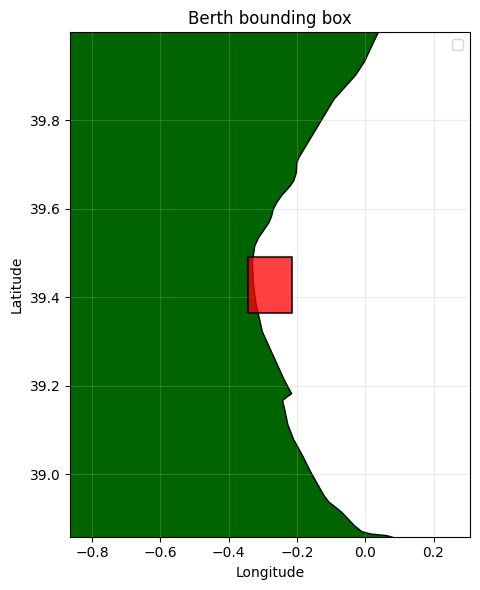

In [838]:
coastline = gpd.read_file("./data/ne_10m_admin_0_countries/ne_10m_admin_0_countries.shp")
draw_bbox(coastline, BBOX)

## Pre-processing

### Defining the population

#### Filter out non-commercial vessels

In [839]:
ais_meta_merged["vessel_type_details"].value_counts(normalize=True).mul(100).round(2)

vessel_type_details
                     64.83
Container Ship       23.16
Roll-on Roll-off      2.51
Chemical Tanker       2.12
Tanker                1.91
General Dry Cargo     1.32
Pure Car Carrier      1.32
Bulk Carrier          1.26
Offshore              1.22
Vehicle/Passenger     0.24
Passenger Ship        0.06
Miscellaneous         0.05
LPG Carrier           0.01
Name: proportion, dtype: float64

In [840]:
VALID_VESSEL_TYPES = ["Bulk Carrier", "General Dry Cargo", "Chemical Tanker", "Container Ship", "Tanker", "LPG Carrier"]

mask = ais_meta_merged["vessel_type_details"].isin(VALID_VESSEL_TYPES)
cargo_ais_meta_merged = ais_meta_merged[mask].copy()
cargo_ais_meta_merged.head()

,voyage_id,voyage_status,mmsi,pos_timestamp,navigation_status,position_accuracy,longitude,latitude,course_over_ground,true_heading,...,arrival_locode,arrival_latitude,arrival_longitude,prev_voyage_id,next_voyage_id,departed_port_call_id,arrived_port_call_id,duration,arrival_country,arrival_date
61,000f779b-5cb3-45da-a836-65e36c713e57,PENDING_DEPARTURE,271044070,2024-05-28 10:12:52,UNDER_WAY_USING_ENGINES,True,-5.526118,35.875667,223.899994,40,...,ESVLC,39.447783,-0.315918,af9f0ac1-d1a9-4edd-9a32-3445054cd8dc,0027ef67-0f9c-45a0-b9be-daecaef9ab98,,,111694.0,ES,2024-05-30
62,000f779b-5cb3-45da-a836-65e36c713e57,PENDING_DEPARTURE,271044070,2024-05-28 10:29:47,MOORED,True,-5.526198,35.875515,220.800003,39,...,ESVLC,39.447783,-0.315918,af9f0ac1-d1a9-4edd-9a32-3445054cd8dc,0027ef67-0f9c-45a0-b9be-daecaef9ab98,,,111694.0,ES,2024-05-30
63,000f779b-5cb3-45da-a836-65e36c713e57,PENDING_DEPARTURE,271044070,2024-05-28 10:58:31,MOORED,True,-5.526250,35.875617,220.800003,41,...,ESVLC,39.447783,-0.315918,af9f0ac1-d1a9-4edd-9a32-3445054cd8dc,0027ef67-0f9c-45a0-b9be-daecaef9ab98,,,111694.0,ES,2024-05-30
64,000f779b-5cb3-45da-a836-65e36c713e57,PENDING_DEPARTURE,271044070,2024-05-28 11:16:30,MOORED,True,-5.526217,35.875567,220.800003,41,...,ESVLC,39.447783,-0.315918,af9f0ac1-d1a9-4edd-9a32-3445054cd8dc,0027ef67-0f9c-45a0-b9be-daecaef9ab98,,,111694.0,ES,2024-05-30
65,000f779b-5cb3-45da-a836-65e36c713e57,PENDING_DEPARTURE,271044070,2024-05-28 11:31:31,MOORED,True,-5.526200,35.875533,220.800003,39,...,ESVLC,39.447783,-0.315918,af9f0ac1-d1a9-4edd-9a32-3445054cd8dc,0027ef67-0f9c-45a0-b9be-daecaef9ab98,,,111694.0,ES,2024-05-30


#### Filter out voyages with invalid voyage status

In [841]:
cargo_ais_meta_merged["voyage_status"].value_counts(normalize=True).mul(100).round(2)

voyage_status
UNDER_WAY            50.95
PENDING_DEPARTURE    31.41
STOPPED              16.97
COMPLETED             0.66
Name: proportion, dtype: float64

In [842]:
VALID_VOYAGE_STATUSES = ["UNDER_WAY", "STOPPED"]

mask = cargo_ais_meta_merged["voyage_status"].isin(VALID_VOYAGE_STATUSES)
cargo_ais_meta_merged = cargo_ais_meta_merged[mask].copy()
cargo_ais_meta_merged.head()

,voyage_id,voyage_status,mmsi,pos_timestamp,navigation_status,position_accuracy,longitude,latitude,course_over_ground,true_heading,...,arrival_locode,arrival_latitude,arrival_longitude,prev_voyage_id,next_voyage_id,departed_port_call_id,arrived_port_call_id,duration,arrival_country,arrival_date
120,000f779b-5cb3-45da-a836-65e36c713e57,UNDER_WAY,271044070,2024-05-29 03:41:23,UNDER_WAY_USING_ENGINES,True,-5.527400,35.876267,270.200012,55,...,ESVLC,39.447783,-0.315918,af9f0ac1-d1a9-4edd-9a32-3445054cd8dc,0027ef67-0f9c-45a0-b9be-daecaef9ab98,,,111694.0,ES,2024-05-30
121,000f779b-5cb3-45da-a836-65e36c713e57,STOPPED,271044070,2024-05-29 03:54:43,UNDER_WAY_USING_ENGINES,True,-5.535050,35.869017,186.899994,13,...,ESVLC,39.447783,-0.315918,af9f0ac1-d1a9-4edd-9a32-3445054cd8dc,0027ef67-0f9c-45a0-b9be-daecaef9ab98,,,111694.0,ES,2024-05-30
122,000f779b-5cb3-45da-a836-65e36c713e57,UNDER_WAY,271044070,2024-05-29 03:57:53,UNDER_WAY_USING_ENGINES,True,-5.534417,35.871585,11.800000,12,...,ESVLC,39.447783,-0.315918,af9f0ac1-d1a9-4edd-9a32-3445054cd8dc,0027ef67-0f9c-45a0-b9be-daecaef9ab98,,,111694.0,ES,2024-05-30
123,000f779b-5cb3-45da-a836-65e36c713e57,UNDER_WAY,271044070,2024-05-29 04:13:22,UNDER_WAY_USING_ENGINES,True,-5.540268,35.917555,347.600006,3,...,ESVLC,39.447783,-0.315918,af9f0ac1-d1a9-4edd-9a32-3445054cd8dc,0027ef67-0f9c-45a0-b9be-daecaef9ab98,,,111694.0,ES,2024-05-30
124,000f779b-5cb3-45da-a836-65e36c713e57,UNDER_WAY,271044070,2024-05-29 04:29:03,UNDER_WAY_USING_ENGINES,True,-5.494577,35.951485,65.699997,65,...,ESVLC,39.447783,-0.315918,af9f0ac1-d1a9-4edd-9a32-3445054cd8dc,0027ef67-0f9c-45a0-b9be-daecaef9ab98,,,111694.0,ES,2024-05-30


#### Filter out voyages with missing MMSI

In [843]:
voyages_with_valid_mmsi_pct = cargo_ais_meta_merged["mmsi"].notna().mean() * 100
print(f"Voyages with valid MMSI: {voyages_with_valid_mmsi_pct:.2f}%")

Voyages with valid MMSI: 100.00%


#### Filter out AIS data past actual time of arrival to isolate the voyage from the "waiting to be berthed" stage

In [844]:
in_bbox = (
    (cargo_ais_meta_merged["latitude"].between(BBOX_MIN_LAT, BBOX_MAX_LAT)) &
    (cargo_ais_meta_merged["longitude"].between(BBOX_MIN_LON, BBOX_MAX_LON))
)

cargo_ais_meta_merged["in_bbox"] = in_bbox

In [845]:
cargo_ais_meta_merged["in_bbox"].sample(10)

2283065     True
1261531    False
1932777     True
2234390    False
2508441    False
1428737    False
1884754    False
3203485     True
965073     False
1935895     True
Name: in_bbox, dtype: bool

In [846]:
cargo_ais_meta_merged.iloc[359223]

voyage_id               8843d835-e502-4ad8-9605-cb6d5989508b
voyage_status                                      UNDER_WAY
mmsi                                               538004911
pos_timestamp                            2024-06-04 07:52:06
navigation_status                    UNDER_WAY_USING_ENGINES
                                        ...                 
arrived_port_call_id                                        
duration                                           1968843.0
arrival_country                                           ES
arrival_date                                      2024-06-13
in_bbox                                                False
Name: 1788559, Length: 66, dtype: object

Above we see that voyage_status: STOPPED, navigation_status: AT_ANCHOR, in_bbox: True, yet tta_hours: 42.156111.
<br>This means the arrival_time is when it HAS berthed and not when it arrived outside the harbor and is waiting for a berthing spot.
<br>Trim all remaining data points after in_bbox becomes true.

In [847]:
# Sort by voyage and time first
df = cargo_ais_meta_merged.sort_values(["voyage_id", "pos_timestamp"])

# For each voyage, find the first index where in_bbox is True
first_in = (
    df[df["in_bbox"]]
    .groupby("voyage_id")["pos_timestamp"]
    .min()
    .rename("first_in_bbox_time")
)

# Join back to df
df = df.merge(first_in, on="voyage_id", how="left")

# Only keep rows before and the exact row where in_bbox true
mask = (df["pos_timestamp"] <= df["first_in_bbox_time"])

cargo_ais_meta_merged = df[mask].copy()
cargo_ais_meta_merged.head()

,voyage_id,voyage_status,mmsi,pos_timestamp,navigation_status,position_accuracy,longitude,latitude,course_over_ground,true_heading,...,arrival_longitude,prev_voyage_id,next_voyage_id,departed_port_call_id,arrived_port_call_id,duration,arrival_country,arrival_date,in_bbox,first_in_bbox_time
0,000f779b-5cb3-45da-a836-65e36c713e57,UNDER_WAY,271044070,2024-05-29 03:41:23,UNDER_WAY_USING_ENGINES,True,-5.527400,35.876267,270.200012,55,...,-0.315918,af9f0ac1-d1a9-4edd-9a32-3445054cd8dc,0027ef67-0f9c-45a0-b9be-daecaef9ab98,,,111694.0,ES,2024-05-30,False,2024-05-30 09:56:34
1,000f779b-5cb3-45da-a836-65e36c713e57,STOPPED,271044070,2024-05-29 03:54:43,UNDER_WAY_USING_ENGINES,True,-5.535050,35.869017,186.899994,13,...,-0.315918,af9f0ac1-d1a9-4edd-9a32-3445054cd8dc,0027ef67-0f9c-45a0-b9be-daecaef9ab98,,,111694.0,ES,2024-05-30,False,2024-05-30 09:56:34
2,000f779b-5cb3-45da-a836-65e36c713e57,UNDER_WAY,271044070,2024-05-29 03:57:53,UNDER_WAY_USING_ENGINES,True,-5.534417,35.871585,11.800000,12,...,-0.315918,af9f0ac1-d1a9-4edd-9a32-3445054cd8dc,0027ef67-0f9c-45a0-b9be-daecaef9ab98,,,111694.0,ES,2024-05-30,False,2024-05-30 09:56:34
3,000f779b-5cb3-45da-a836-65e36c713e57,UNDER_WAY,271044070,2024-05-29 04:13:22,UNDER_WAY_USING_ENGINES,True,-5.540268,35.917555,347.600006,3,...,-0.315918,af9f0ac1-d1a9-4edd-9a32-3445054cd8dc,0027ef67-0f9c-45a0-b9be-daecaef9ab98,,,111694.0,ES,2024-05-30,False,2024-05-30 09:56:34
4,000f779b-5cb3-45da-a836-65e36c713e57,UNDER_WAY,271044070,2024-05-29 04:29:03,UNDER_WAY_USING_ENGINES,True,-5.494577,35.951485,65.699997,65,...,-0.315918,af9f0ac1-d1a9-4edd-9a32-3445054cd8dc,0027ef67-0f9c-45a0-b9be-daecaef9ab98,,,111694.0,ES,2024-05-30,False,2024-05-30 09:56:34


#### Filter out voyages with invalid navigation statuses

In [848]:
cargo_ais_meta_merged["navigation_status"].value_counts(normalize=True).mul(100).round(2)

navigation_status
UNDER_WAY_USING_ENGINES              95.45
AT_ANCHOR                             2.23
MOORED                                1.56
UNDER_WAY_SAILING                     0.52
NOT_UNDER_COMMAND                     0.14
CONSTRAINED_BY_HER_DRAUGHT            0.04
RESTRICTED_MANEUVERABILITY            0.03
UNDEFINED                             0.02
PUSHING_AHEAD_OR_TOWING_ALONGSIDE     0.01
AGROUND                               0.00
Name: proportion, dtype: float64

In [849]:
VALID_NAVIGATION_STATUSES = [
       'UNDER_WAY_USING_ENGINES', 'MOORED', 'AT_ANCHOR',
       'CONSTRAINED_BY_HER_DRAUGHT', 'UNDER_WAY_SAILING',
       'RESTRICTED_MANEUVERABILITY',
       'PUSHING_AHEAD_OR_TOWING_ALONGSIDE']

mask = cargo_ais_meta_merged["navigation_status"].isin(VALID_NAVIGATION_STATUSES)
cargo_ais_meta_merged = cargo_ais_meta_merged[mask].copy()
cargo_ais_meta_merged.head()

,voyage_id,voyage_status,mmsi,pos_timestamp,navigation_status,position_accuracy,longitude,latitude,course_over_ground,true_heading,...,arrival_longitude,prev_voyage_id,next_voyage_id,departed_port_call_id,arrived_port_call_id,duration,arrival_country,arrival_date,in_bbox,first_in_bbox_time
0,000f779b-5cb3-45da-a836-65e36c713e57,UNDER_WAY,271044070,2024-05-29 03:41:23,UNDER_WAY_USING_ENGINES,True,-5.527400,35.876267,270.200012,55,...,-0.315918,af9f0ac1-d1a9-4edd-9a32-3445054cd8dc,0027ef67-0f9c-45a0-b9be-daecaef9ab98,,,111694.0,ES,2024-05-30,False,2024-05-30 09:56:34
1,000f779b-5cb3-45da-a836-65e36c713e57,STOPPED,271044070,2024-05-29 03:54:43,UNDER_WAY_USING_ENGINES,True,-5.535050,35.869017,186.899994,13,...,-0.315918,af9f0ac1-d1a9-4edd-9a32-3445054cd8dc,0027ef67-0f9c-45a0-b9be-daecaef9ab98,,,111694.0,ES,2024-05-30,False,2024-05-30 09:56:34
2,000f779b-5cb3-45da-a836-65e36c713e57,UNDER_WAY,271044070,2024-05-29 03:57:53,UNDER_WAY_USING_ENGINES,True,-5.534417,35.871585,11.800000,12,...,-0.315918,af9f0ac1-d1a9-4edd-9a32-3445054cd8dc,0027ef67-0f9c-45a0-b9be-daecaef9ab98,,,111694.0,ES,2024-05-30,False,2024-05-30 09:56:34
3,000f779b-5cb3-45da-a836-65e36c713e57,UNDER_WAY,271044070,2024-05-29 04:13:22,UNDER_WAY_USING_ENGINES,True,-5.540268,35.917555,347.600006,3,...,-0.315918,af9f0ac1-d1a9-4edd-9a32-3445054cd8dc,0027ef67-0f9c-45a0-b9be-daecaef9ab98,,,111694.0,ES,2024-05-30,False,2024-05-30 09:56:34
4,000f779b-5cb3-45da-a836-65e36c713e57,UNDER_WAY,271044070,2024-05-29 04:29:03,UNDER_WAY_USING_ENGINES,True,-5.494577,35.951485,65.699997,65,...,-0.315918,af9f0ac1-d1a9-4edd-9a32-3445054cd8dc,0027ef67-0f9c-45a0-b9be-daecaef9ab98,,,111694.0,ES,2024-05-30,False,2024-05-30 09:56:34


In [850]:
cargo_ais_meta_merged.columns

Index(['voyage_id', 'voyage_status', 'mmsi', 'pos_timestamp',
       'navigation_status', 'position_accuracy', 'longitude', 'latitude',
       'course_over_ground', 'true_heading', 'timestamp_seconds', 'raim',
       'rate_of_turn', 'speed_over_ground', 'pos_source', 'call_sign', 'name',
       'ship_type', 'ref_point_a', 'ref_point_b', 'ref_point_c', 'ref_point_d',
       'position_device', 'eta', 'draught', 'destination', 'meta_timestamp',
       'imo', 'meta_source', 'flag', 'build_year', 'length', 'width',
       'capacity_dwt', 'manager', 'owner', 'builder', 'class_society',
       'capacity_gt', 'capacity_teu', 'capacity_liquid_gas',
       'capacity_passenger', 'capacity_liquid_oil', 'commercial_size_class',
       'vessel_type_details', 'draught_max', 'draught_min', 'capacity_nt',
       'vid_prefix', 'month', 'departure_time', 'departure_locode',
       'departure_latitude', 'departure_longitude', 'arrival_time',
       'arrival_locode', 'arrival_latitude', 'arrival_longitude'

### Outlier detection and removal

#### Duration

In [851]:
print(f"Duration (minutes): \n{cargo_ais_meta_merged["duration"].describe().div(60).round(2)}")

Duration (minutes): 
count      7648.00
mean      18136.02
std       18412.03
min           2.00
25%        3511.10
50%        9446.25
75%       35912.32
max      187349.28
Name: duration, dtype: float64


In [852]:
lower_q = 0.01
upper_q = 0.99

q_low  = cargo_ais_meta_merged["duration"].quantile(lower_q)
q_high = cargo_ais_meta_merged["duration"].quantile(upper_q)

mask = (cargo_ais_meta_merged["duration"] >= q_low) & (cargo_ais_meta_merged["duration"] <= q_high)
cargo_ais_meta_merged = cargo_ais_meta_merged[mask].copy()

In [853]:
print(f"Duration (minutes): \n{cargo_ais_meta_merged["duration"].describe().div(60).round(2)}")

Duration (minutes): 
count     7562.10
mean     18186.29
std      18035.96
min        220.50
25%       3656.55
50%       9622.73
75%      35935.22
max      97635.92
Name: duration, dtype: float64


#### SOG

In [854]:
cargo_ais_meta_merged["speed_over_ground"].describe()

count    453726.000000
mean         12.728731
std           5.241297
min           0.000000
25%          10.600000
50%          13.400000
75%          16.500000
max         102.300003
Name: speed_over_ground, dtype: float64

Max SOG is extremely high, lets plot it

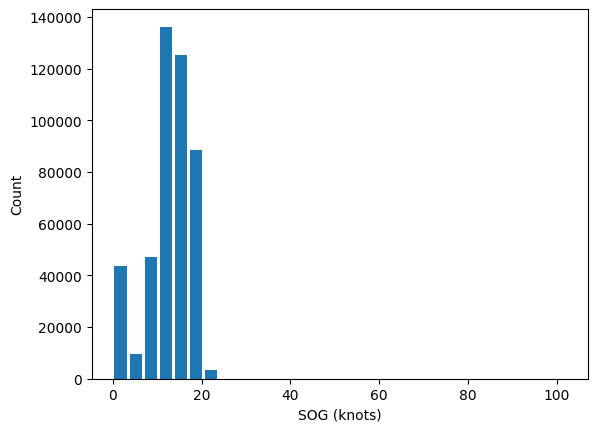

In [855]:
plt.hist(cargo_ais_meta_merged["speed_over_ground"], rwidth=0.8, bins=30)
plt.xlabel("SOG (knots)")
plt.ylabel("Count")
plt.show()

We also have lots of entries with SOG of 0, keep them as is for now and just remove  the upper 1% quantile outliers.

In [856]:
upper_q = 0.99

q_high = cargo_ais_meta_merged["speed_over_ground"].quantile(upper_q)

mask = cargo_ais_meta_merged["speed_over_ground"] <= q_high
cargo_ais_meta_merged = cargo_ais_meta_merged[mask].copy()

In [857]:
cargo_ais_meta_merged["speed_over_ground"].describe()

count    449672.000000
mean         12.635257
std           5.040090
min           0.000000
25%          10.600000
50%          13.300000
75%          16.400000
max          20.299999
Name: speed_over_ground, dtype: float64

We now get way more realistic SOG values.

#### Coords

Longitude is expected to be [-180;180].

In [858]:
cargo_ais_meta_merged["longitude"].describe()

count    449672.000000
mean          3.043586
std          24.170278
min         -95.012603
25%          -6.312437
50%          -0.003707
75%           7.553865
max         123.033823
Name: longitude, dtype: float64

Latitude is expected to be [-90;90].

In [859]:
cargo_ais_meta_merged["latitude"].describe()

count    449672.000000
mean         26.982274
std          21.707269
min         -35.536462
25%          26.476939
50%          36.497215
75%          39.310195
max          60.196253
Name: latitude, dtype: float64

No impossible coords detected.

Lets look at a data sample with a stop mid-journey

## Feature engineering

#### Calculate delta longitude and latitude

Covert to scalar distance (km) from degrees (mixes direction and scale)?

In [860]:
cargo_ais_meta_merged["delta_lon"] = cargo_ais_meta_merged.groupby("voyage_id")["longitude"].diff()
cargo_ais_meta_merged["delta_lon"].describe()

count    446383.000000
mean         -0.031662
std           0.358555
min        -115.782982
25%          -0.078703
50%          -0.023317
75%           0.048849
max          51.788637
Name: delta_lon, dtype: float64

In [861]:
cargo_ais_meta_merged["delta_lat"] = cargo_ais_meta_merged.groupby("voyage_id")["latitude"].diff()
cargo_ais_meta_merged["delta_lat"].describe()

count    446383.000000
mean          0.017061
std           0.293414
min         -80.748948
25%          -0.020146
50%           0.010673
75%           0.052187
max          80.516758
Name: delta_lat, dtype: float64

Distance in km using haversine

In [862]:
import numpy as np

R = 6371.0  # Earth radius in km

cargo_ais_meta_merged = cargo_ais_meta_merged.sort_values(["voyage_id", "pos_timestamp"])

lat1 = np.radians(cargo_ais_meta_merged["latitude"].shift(1))   # global shift
dlat = np.radians(cargo_ais_meta_merged["delta_lat"])
dlon = np.radians(cargo_ais_meta_merged["delta_lon"])

a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat1 + dlat) * np.sin(dlon / 2)**2

c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

cargo_ais_meta_merged["delta_dist_km"] = R * c


In [863]:
cargo_ais_meta_merged["delta_dist_km"].describe()

count    446383.000000
mean         14.039884
std          44.975571
min           0.000000
25%           5.641863
50%           7.933226
75%          13.016498
max       12876.494261
Name: delta_dist_km, dtype: float64

In [864]:
sus = cargo_ais_meta_merged.sort_values("delta_dist_km", ascending=False).copy().head()
sus[["voyage_id","pos_timestamp","latitude","longitude","delta_dist_km","speed_over_ground"]]

,voyage_id,pos_timestamp,latitude,longitude,delta_dist_km,speed_over_ground
446576,a9b6885e-0dec-4da5-9d60-f5b46bf3177a,2024-09-29 10:31:43,29.840950,-12.198432,12876.494261,15.1
79247,1c05b473-b1d8-4a82-a142-5a706a01db43,2024-02-07 22:38:49,-26.565022,34.624563,9753.374656,19.1
79246,1c05b473-b1d8-4a82-a142-5a706a01db43,2024-02-07 22:16:23,54.183927,-5.106110,9737.352950,10.7
542190,c9fafcfb-af11-401f-81b1-3625e49ad252,2024-02-26 14:54:42,34.996833,-21.408000,6698.287734,10.1
542189,c9fafcfb-af11-401f-81b1-3625e49ad252,2024-02-26 12:57:40,-22.350705,-40.840792,6680.852194,11.7


In [865]:
MAX_DELTA_DIST_KM = 500

# Step 1: Find voyages with ANY step > 500km (long voyages)
mask = cargo_ais_meta_merged["delta_dist_km"] > MAX_DELTA_DIST_KM
long_voyage_ids = cargo_ais_meta_merged.loc[mask, "voyage_id"].unique()

# Step 2: Keep ALL rows from those voyages
long_voyages_df = cargo_ais_meta_merged[
    cargo_ais_meta_merged["voyage_id"].isin(long_voyage_ids)
].copy()

print(f"Kept {len(long_voyage_ids)} long voyages")

Kept 102 long voyages


Found 102 voyages.


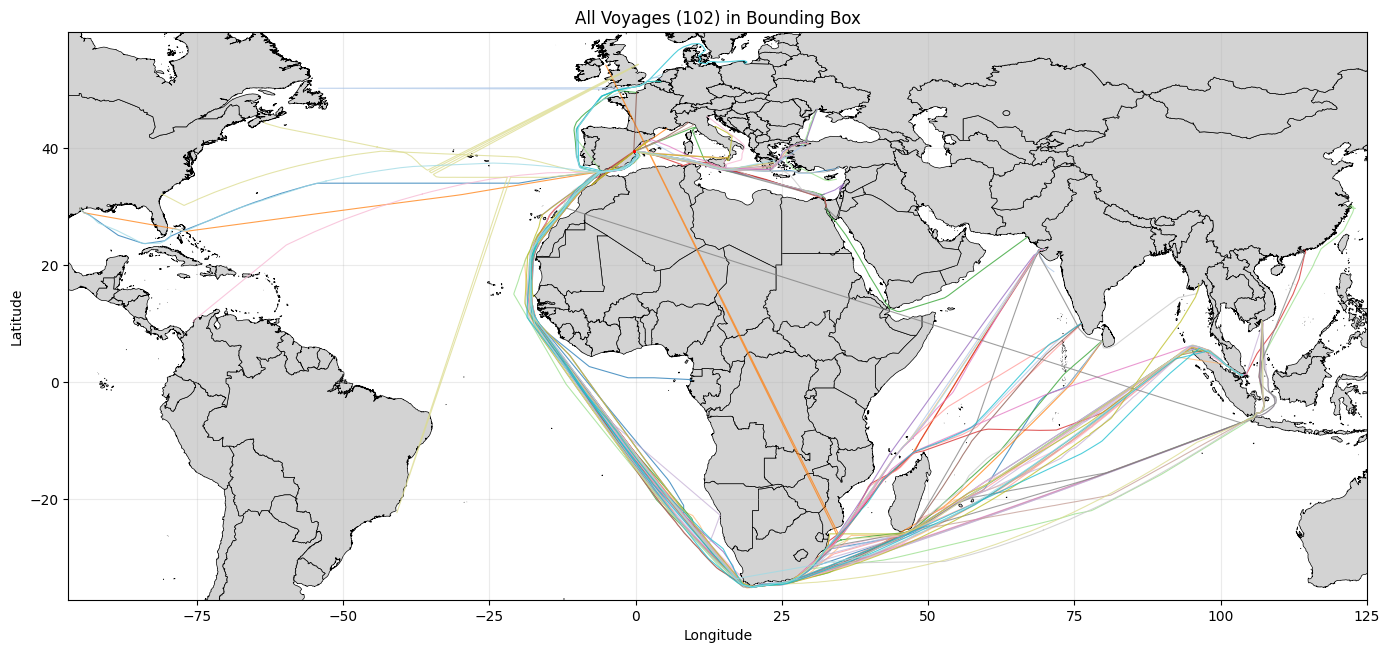

In [866]:
plot_all_voyages(long_voyages_df, coastline, BBOX)

Remove any data points with an unrealistically high max delta dist km

In [867]:
MAX_DELTA_DIST_KM = 500

# 1) Find voyages that have at least one bad delta
bad_voyages = cargo_ais_meta_merged.loc[
    cargo_ais_meta_merged["delta_dist_km"] > MAX_DELTA_DIST_KM,
    "voyage_id"
].unique()

print(f"Bad voyages (delta_dist_km > 500km): {len(bad_voyages)}")

# 2) Keep only voyages that are not in bad_voyages
cargo_ais_meta_merged = cargo_ais_meta_merged[
    ~cargo_ais_meta_merged["voyage_id"].isin(bad_voyages)
].copy()

Bad voyages (delta_dist_km > 500km): 102


In [868]:
cargo_ais_meta_merged["delta_dist_km"].describe()

count    397013.000000
mean         12.633988
std          19.674532
min           0.000000
25%           5.500838
50%           7.535416
75%          11.754485
max         494.577033
Name: delta_dist_km, dtype: float64

In [869]:
cargo_ais_meta_merged["total_dist_km"] = cargo_ais_meta_merged.groupby("voyage_id")["delta_dist_km"].transform("sum")

In [870]:
cargo_ais_meta_merged["total_dist_km"].describe()

count    400200.000000
mean       6066.543889
std        7143.204978
min           0.000000
25%         948.229897
50%        3037.945130
75%        7823.471859
max       22049.755548
Name: total_dist_km, dtype: float64

In [871]:
cargo_ais_meta_merged[cargo_ais_meta_merged["total_dist_km"] == cargo_ais_meta_merged["total_dist_km"].max()]

,voyage_id,voyage_status,mmsi,pos_timestamp,navigation_status,position_accuracy,longitude,latitude,course_over_ground,true_heading,...,arrived_port_call_id,duration,arrival_country,arrival_date,in_bbox,first_in_bbox_time,delta_lon,delta_lat,delta_dist_km,total_dist_km
355521,8699e52a-ff7d-4ceb-a96c-c579df6c6ff2,UNDER_WAY,538007580,2024-02-28 02:04:39,UNDER_WAY_USING_ENGINES,False,86.668838,20.277845,213.100006,206,...,,4898092.0,ES,2024-04-24,False,2024-04-23 12:57:58,NaN,NaN,NaN,22049.755548
355522,8699e52a-ff7d-4ceb-a96c-c579df6c6ff2,UNDER_WAY,538007580,2024-02-28 02:24:40,UNDER_WAY_USING_ENGINES,False,86.674592,20.265197,136.199997,131,...,,4898092.0,ES,2024-04-24,False,2024-04-23 12:57:58,0.005753,-0.012648,1.529113,22049.755548
355523,8699e52a-ff7d-4ceb-a96c-c579df6c6ff2,UNDER_WAY,538007580,2024-02-28 02:44:40,UNDER_WAY_USING_ENGINES,False,86.721283,20.238638,123.000000,122,...,,4898092.0,ES,2024-04-24,False,2024-04-23 12:57:58,0.046692,-0.026558,5.696218,22049.755548
355524,8699e52a-ff7d-4ceb-a96c-c579df6c6ff2,UNDER_WAY,538007580,2024-02-28 03:04:40,UNDER_WAY_USING_ENGINES,False,86.772883,20.192558,139.899994,137,...,,4898092.0,ES,2024-04-24,False,2024-04-23 12:57:58,0.051600,-0.046080,7.432611,22049.755548
355525,8699e52a-ff7d-4ceb-a96c-c579df6c6ff2,UNDER_WAY,538007580,2024-02-28 03:24:40,UNDER_WAY_USING_ENGINES,False,86.829237,20.150410,122.099998,121,...,,4898092.0,ES,2024-04-24,False,2024-04-23 12:57:58,0.056353,-0.042148,7.520726,22049.755548
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
356685,8699e52a-ff7d-4ceb-a96c-c579df6c6ff2,UNDER_WAY,538007580,2024-04-23 11:52:03,UNDER_WAY_USING_ENGINES,False,-0.078607,39.314038,318.100006,318,...,,4898092.0,ES,2024-04-24,False,2024-04-23 12:57:58,-0.045320,0.039655,5.886674,22049.755548
356686,8699e52a-ff7d-4ceb-a96c-c579df6c6ff2,UNDER_WAY,538007580,2024-04-23 12:09:34,UNDER_WAY_USING_ENGINES,False,-0.128705,39.358165,318.799988,318,...,,4898092.0,ES,2024-04-24,False,2024-04-23 12:57:58,-0.050098,0.044127,6.529877,22049.755548
356687,8699e52a-ff7d-4ceb-a96c-c579df6c6ff2,UNDER_WAY,538007580,2024-04-23 12:26:00,UNDER_WAY_USING_ENGINES,False,-0.170845,39.379592,286.600006,280,...,,4898092.0,ES,2024-04-24,False,2024-04-23 12:57:58,-0.042140,0.021427,4.335742,22049.755548
356688,8699e52a-ff7d-4ceb-a96c-c579df6c6ff2,UNDER_WAY,538007580,2024-04-23 12:41:12,UNDER_WAY_USING_ENGINES,False,-0.208430,39.384683,278.600006,275,...,,4898092.0,ES,2024-04-24,False,2024-04-23 12:57:58,-0.037585,0.005092,3.279523,22049.755548


/tmp/ipykernel_7014/569726036.py:43: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


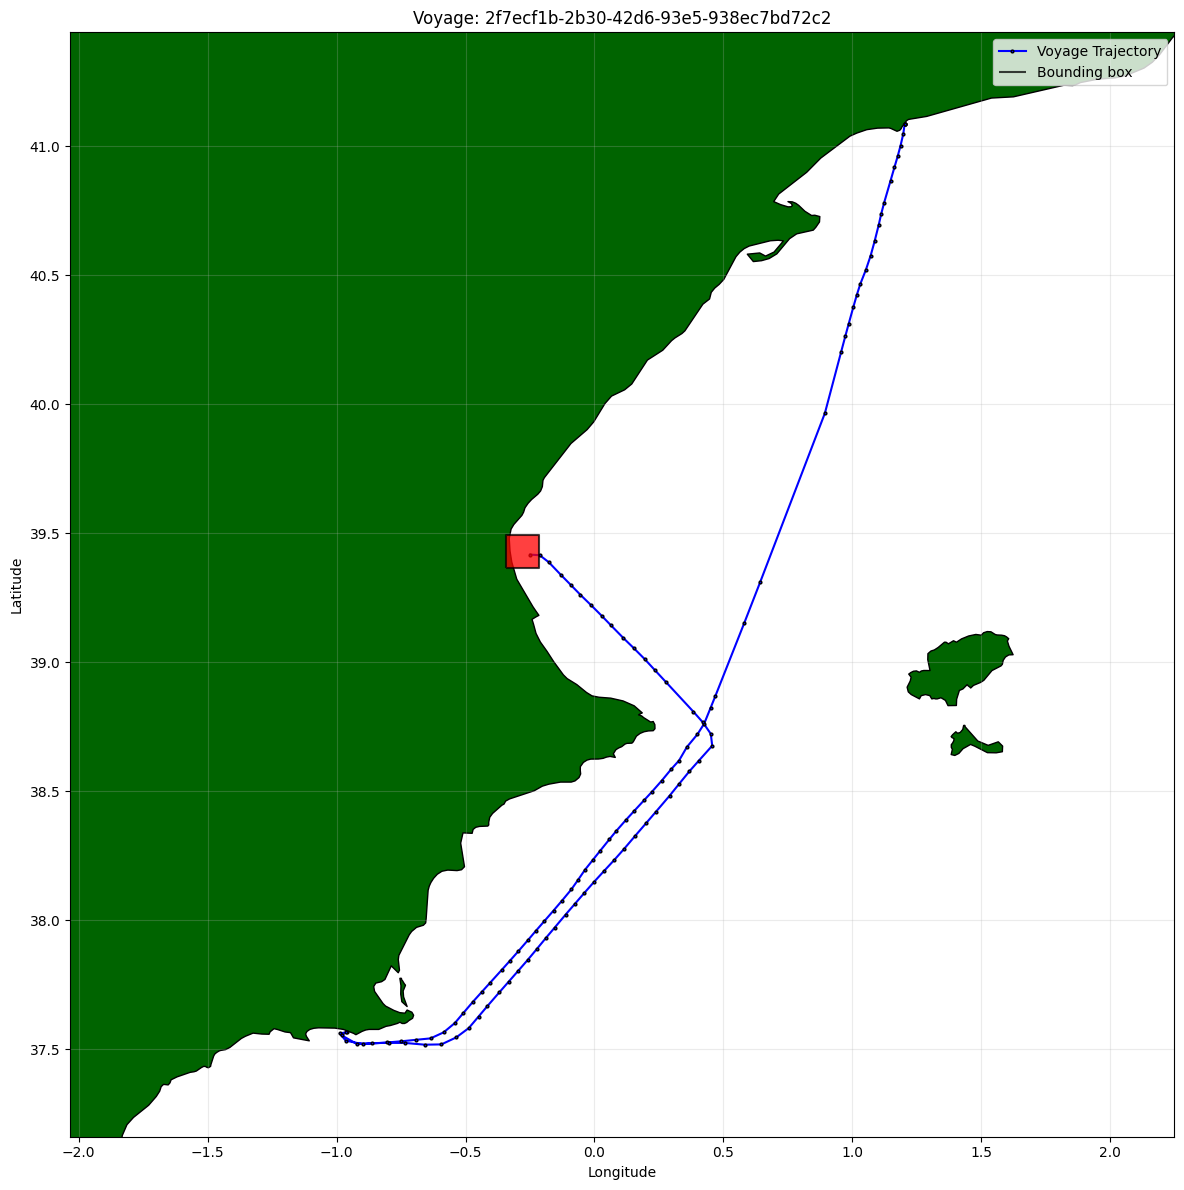

Voyage: 2f7ecf1b-2b30-42d6-93e5-938ec7bd72c2 
Total traveled distance: 768.61 km
Duration: 59.73 hours
Data points: 116


In [872]:
voyage_df = cargo_ais_meta_merged[cargo_ais_meta_merged["voyage_id"] == "2f7ecf1b-2b30-42d6-93e5-938ec7bd72c2"].copy()
plot_voyage_on_coastline(voyage_df, coastline, BBOX)

#### Remove voyages with less than 10 data points

In [873]:
points_per_voyage = cargo_ais_meta_merged.groupby('voyage_id').size()
points_per_voyage.describe()

count    3187.000000
mean      125.572639
std       195.549633
min         1.000000
25%        27.000000
50%        63.000000
75%       138.000000
max      4060.000000
dtype: float64

In [874]:
valid_voyages = points_per_voyage[points_per_voyage >= 10].index

cargo_ais_meta_merged = cargo_ais_meta_merged[
    cargo_ais_meta_merged['voyage_id'].isin(valid_voyages)
]

In [875]:
len(cargo_ais_meta_merged["voyage_id"].unique())

2785

#### Calculate course deviation and include as feature<br>
Course deviation helps accomodate for wind and waves physically causing the vessel to mode in a different direction than where it's pointing.<br>
Vessel can't deviate by more than 360 degrees total, so map to -180,180 degrees.

In [876]:
diff = cargo_ais_meta_merged["course_over_ground"] - cargo_ais_meta_merged["true_heading"]
cargo_ais_meta_merged["deg_off_course"] = ((diff + 180) % 360) - 180
cargo_ais_meta_merged["deg_off_course"].describe()

count    399502.000000
mean         -0.505881
std          35.881115
min        -180.000000
25%          -1.599998
50%           0.099998
75%           1.800003
max         179.900002
Name: deg_off_course, dtype: float64

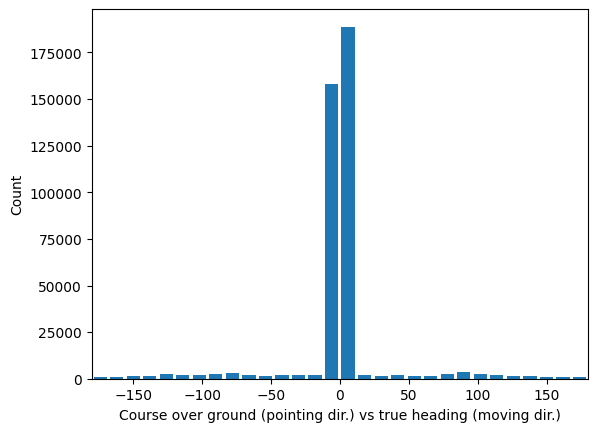

In [877]:
plt.hist(cargo_ais_meta_merged["deg_off_course"], rwidth=0.8, bins=30)
plt.xlim(-180, 180)
plt.xlabel("Course over ground (pointing dir.) vs true heading (moving dir.)")
plt.ylabel("Count")
plt.show()

### Include time-to-arrival (TTA) as feature (arrival time - timestamp)

In [878]:
cargo_ais_meta_merged["tta"] = cargo_ais_meta_merged["first_in_bbox_time"] - cargo_ais_meta_merged["pos_timestamp"]
cargo_ais_meta_merged["tta"].describe()

count                       399502
mean     4 days 13:03:47.523721706
std      6 days 18:42:10.470411283
min                0 days 00:00:00
25%         0 days 12:39:11.250000
50%                1 days 18:49:31
75%         5 days 07:25:06.750000
max               64 days 04:52:28
Name: tta, dtype: object

In [879]:
cargo_ais_meta_merged["tta_hours"] = cargo_ais_meta_merged["tta"].dt.total_seconds() / 3600
cargo_ais_meta_merged["tta_hours"].describe().round(2)

count    399502.00
mean        109.06
std         162.70
min           0.00
25%          12.65
50%          42.83
75%         127.42
max        1540.87
Name: tta_hours, dtype: float64

Filter out voyages with a total distance less than 22 km (nearest port) or with tta_hours < (22 km/max_speed)

In [880]:
TTA_LIM = 22 / (cargo_ais_meta_merged["speed_over_ground"].max() * 1.852)

df = cargo_ais_meta_merged.sort_values(["voyage_id", "pos_timestamp"]).copy()
first_tta = df.groupby("voyage_id")["tta_hours"].first()

mask = first_tta < TTA_LIM
voyage_ids_start_lt_lim = first_tta[mask].index
# assign to cargo ais meta merged if wanting to use this version
voyages_start_lt_tta = df[df["voyage_id"].isin(voyage_ids_start_lt_lim)].copy()

print(f"{voyages_start_lt_tta["tta_hours"].describe()} \n")
print(f"{(voyages_start_lt_tta["duration"].describe() / 3600).round(2)} \n")
print(f"{voyages_start_lt_tta["total_dist_km"].describe()} \n")


count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: tta_hours, dtype: float64 

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: duration, dtype: float64 

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: total_dist_km, dtype: float64 



In [881]:
DIST_LIM_UPPER = 22

# Find voyage_ids with less than 22 km total distance
mask = cargo_ais_meta_merged["total_dist_km"] < DIST_LIM_UPPER
voyage_ids_lt_dist_lim = cargo_ais_meta_merged.loc[mask, "voyage_id"].unique()

# Keep only voyages that are NOT in that list
cargo_ais_meta_merged = cargo_ais_meta_merged[
    ~cargo_ais_meta_merged["voyage_id"].isin(voyage_ids_lt_dist_lim)
].copy()

print(cargo_ais_meta_merged["total_dist_km"].describe())

count    398869.000000
mean       6086.704845
std        7146.567100
min          22.148848
25%         952.607749
50%        3038.227751
75%        7823.471859
max       22049.755548
Name: total_dist_km, dtype: float64


#### Include accumulative and remaining TTA as feature

In [882]:
cargo_ais_meta_merged = cargo_ais_meta_merged.sort_values(['voyage_id', 'pos_timestamp'])

# Group by voyage and accumulate distance traveled
cargo_ais_meta_merged['accumulated_dist_km'] = (
    cargo_ais_meta_merged
    .groupby('voyage_id')['delta_dist_km']
    .cumsum()
)

# Remaining distance
cargo_ais_meta_merged['remaining_dist_km'] = (
    cargo_ais_meta_merged['total_dist_km'] -
    cargo_ais_meta_merged['accumulated_dist_km']
)

In [883]:
cargo_ais_meta_merged[cargo_ais_meta_merged["voyage_id"] == cargo_ais_meta_merged["voyage_id"].iloc[0]]["remaining_dist_km"].head()


0           NaN
1    770.207479
2    769.916247
3    764.777510
4    759.195626
Name: remaining_dist_km, dtype: float64

### Include loading_pct as feauture (draught/max_draught)

In [884]:
cargo_ais_meta_merged["draught"].describe()

count    398869.000000
mean         10.459050
std           3.230604
min           0.000000
25%           7.800000
50%          10.100000
75%          13.000000
max          25.500000
Name: draught, dtype: float64

In [885]:
(cargo_ais_meta_merged["draught"].isna().mean() * 100).round(2)

np.float64(0.0)

In [886]:
cargo_ais_meta_merged["draught_max"].describe()

count    398869.000000
mean          7.606352
std           6.202970
min           0.000000
25%           0.000000
50%           9.200000
75%          13.000000
max          19.800000
Name: draught_max, dtype: float64

In [887]:
(cargo_ais_meta_merged["draught_max"].isna().mean() * 100).round(2)

np.float64(0.0)

Since we can't divide by 0, make 0 NaN

In [888]:
import numpy as np
cargo_ais_meta_merged["draught_max"] = cargo_ais_meta_merged["draught_max"].replace(0, np.nan)

About 1/3 is missing draught_max
<br>Impute draught_max for missing vessels? Better if you don’t want to lose 1/3 of data:
<br>Group by vessel identity (e.g. mmsi or ship_type + commercial_size_class) and fill missing draught_max with a typical value in that group.​

In [889]:
cargo_ais_meta_merged["loading_pct"] = cargo_ais_meta_merged["draught"] / cargo_ais_meta_merged["draught_max"]
cargo_ais_meta_merged["loading_pct"].describe()

count    252604.000000
mean          0.831229
std           0.124014
min           0.000000
25%           0.731343
50%           0.826087
75%           0.930000
max           2.236842
Name: loading_pct, dtype: float64

In [890]:
over = cargo_ais_meta_merged[cargo_ais_meta_merged["loading_pct"] > 1.0]
over[["mmsi", "voyage_id", "draught", "draught_max"]].shape[0]

18733

### Select features

add 1 size proxy varaible

raim seems to not matter, same for rate_of_turn

Haversine fast but inaccurate

In [891]:
from geopy.distance import geodesic

def calc_remaining_dist(row):
    current = (row['latitude'], row['longitude'])
    arrival = (row['arrival_latitude'], row['arrival_longitude'])
    return geodesic(current, arrival).km

In [892]:
cargo_ais_meta_merged['remaining_dist_live'] = cargo_ais_meta_merged.apply(
    calc_remaining_dist, axis=1
)

In [893]:
def get_features(df: pd.DataFrame) -> pd.DataFrame:
    feature_cols = ["deg_off_course", "voyage_status", "navigation_status", "loading_pct", "position_accuracy", "delta_dist_km", "remaining_dist_live", "speed_over_ground", "draught", "build_year", "month", "length", "width", "capacity_nt", "capacity_dwt", "position_device"]
    features = df[feature_cols]
    features.shape
    return features

In [938]:
features = get_features(filtered_100km)

In [939]:
features.head()

,deg_off_course,voyage_status,navigation_status,loading_pct,position_accuracy,delta_dist_km,remaining_dist_live,speed_over_ground,draught,build_year,month,length,width,capacity_nt,capacity_dwt,position_device
96,1.000000,UNDER_WAY,UNDER_WAY_USING_ENGINES,NaN,True,6.413452,95.421175,13.8,9.2,2005,2024-05,207.0,30.0,12591,33796,GPS
97,-0.600006,UNDER_WAY,UNDER_WAY_USING_ENGINES,NaN,True,6.856011,88.892090,13.5,9.2,2005,2024-05,207.0,30.0,12591,33796,GPS
98,-2.100006,UNDER_WAY,UNDER_WAY_USING_ENGINES,NaN,True,7.404978,81.484280,14.1,9.2,2005,2024-05,207.0,30.0,12591,33796,GPS
99,-3.500000,UNDER_WAY,UNDER_WAY_USING_ENGINES,NaN,True,7.338245,74.151004,13.9,9.2,2005,2024-05,207.0,30.0,12591,33796,GPS
100,-1.700012,UNDER_WAY,UNDER_WAY_USING_ENGINES,NaN,True,7.294278,66.911500,14.1,9.2,2005,2024-05,207.0,30.0,12591,33796,GPS


### Heat map to display feature correlations

In [896]:
import seaborn as sns

def plot_heatmap(df: pd.DataFrame) -> None:
    num_df = df.select_dtypes(include=["number"])
    corr = num_df.corr()

    plt.figure(figsize=(14, 12))
    sns.heatmap(corr, cmap="coolwarm", annot=True, fmt=".2f", center=0)
    plt.title("Feature correlation heatmap")
    plt.tight_layout()
    plt.show()

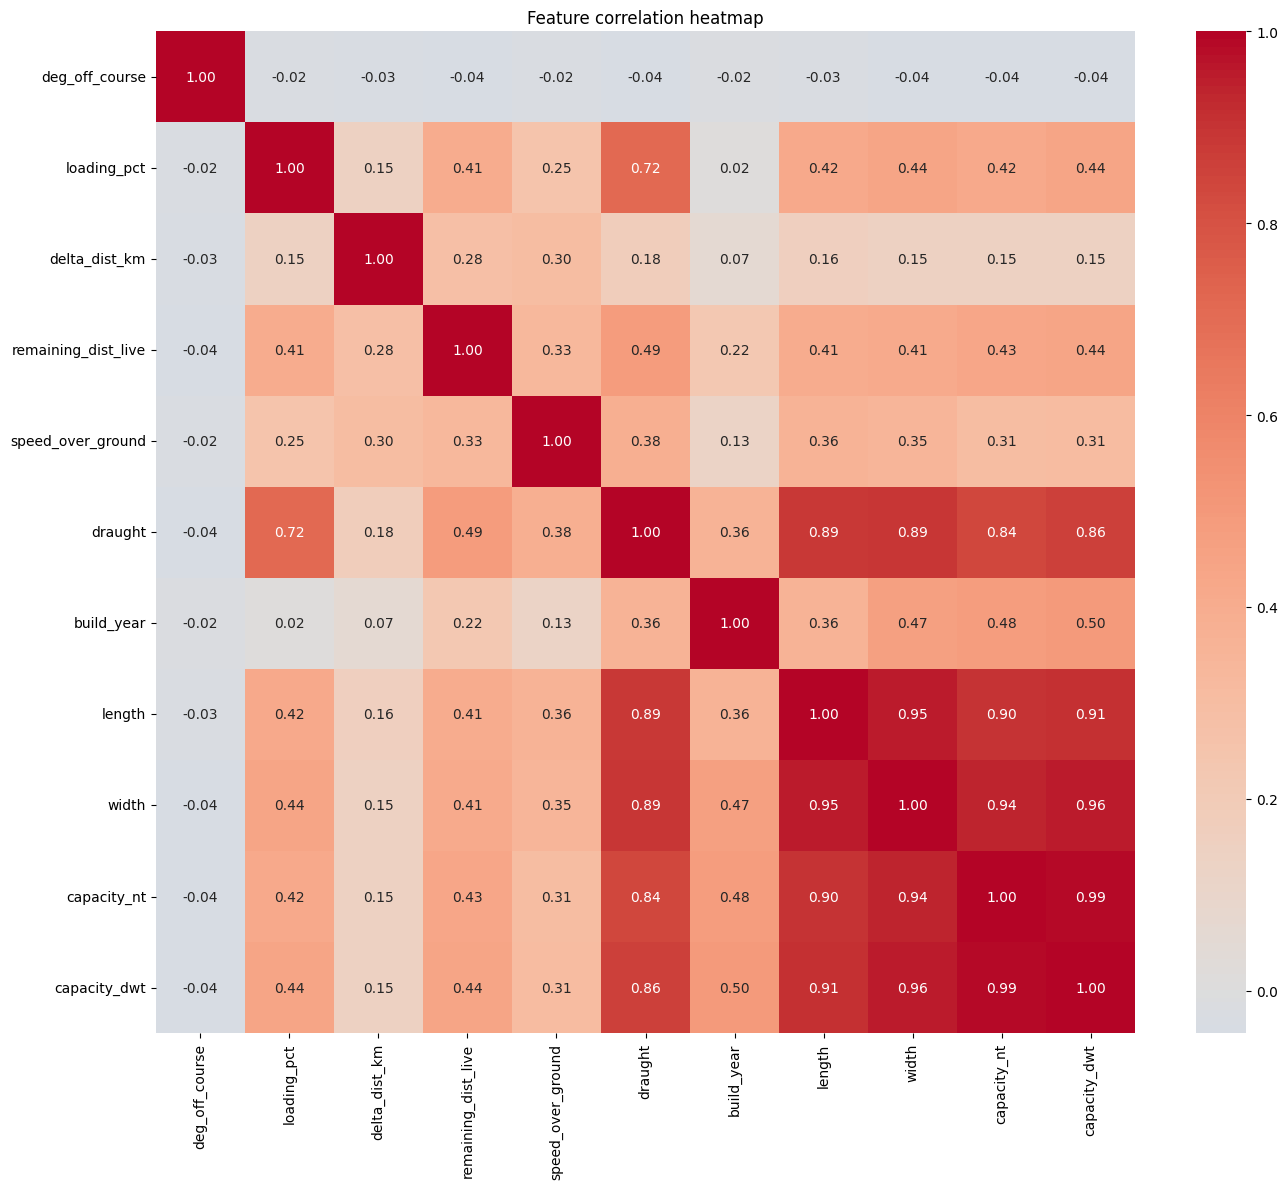

In [897]:
plot_heatmap(features)

We observe that draught, length, width, capacity_dwt, capacity_gw, capacity_teu, capacity_nt are all highly correlated.<br>
Perhaps we can combine these features into a singular feature.

## Export valid AIS samples to csv

In [898]:
def export_voyage_ids_to_csv(df: pd.DataFrame, out: str) -> None:
    valid_voyage_ids = df["voyage_id"].unique()
    valid_voyage_ids_df = pd.DataFrame({"voyage_id": valid_voyage_ids})
    
    valid_voyage_ids_df.to_csv(
        out + ".csv",
        index=False,
        encoding="utf-8",
)

In [899]:
def get_valid_voyages_pct(df: pd.DataFrame, og_df: pd.DataFrame) -> float:
    valid_voyage_ids = df["voyage_id"].unique()
    valid_voyages_pct = valid_voyage_ids.shape[0]/len(arrivals_ais_data["voyage_id"].unique()) * 100
    return valid_voyages_pct

In [900]:
print(f"Valid voyages: {get_valid_voyages_pct(cargo_ais_meta_merged, ais_meta_merged):.2f}%")

Valid voyages: 6.34%


## Model development

In [940]:
features = features.copy()
features['month'] = pd.to_datetime(features['month']).dt.month  # '2024-01' → 1

In [941]:
def split_train_val_data(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    df_model = df.copy()

    # 3) Build X, y
    X = features
    y = df_model["tta_hours"]

    # 4) Time-based split
    split_idx = int(len(df_model) * 0.8)
    X_train, X_val = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_val = y.iloc[:split_idx], y.iloc[split_idx:]

    return X_train, X_val, y_train, y_val

In [942]:
X_train, X_val, y_train, y_val = split_train_val_data(filtered_100km)

In [943]:
X_train.shape

(47452, 16)

In [944]:
X_train.head()

,deg_off_course,voyage_status,navigation_status,loading_pct,position_accuracy,delta_dist_km,remaining_dist_live,speed_over_ground,draught,build_year,month,length,width,capacity_nt,capacity_dwt,position_device
96,1.000000,UNDER_WAY,UNDER_WAY_USING_ENGINES,NaN,True,6.413452,95.421175,13.8,9.2,2005,5,207.0,30.0,12591,33796,GPS
97,-0.600006,UNDER_WAY,UNDER_WAY_USING_ENGINES,NaN,True,6.856011,88.892090,13.5,9.2,2005,5,207.0,30.0,12591,33796,GPS
98,-2.100006,UNDER_WAY,UNDER_WAY_USING_ENGINES,NaN,True,7.404978,81.484280,14.1,9.2,2005,5,207.0,30.0,12591,33796,GPS
99,-3.500000,UNDER_WAY,UNDER_WAY_USING_ENGINES,NaN,True,7.338245,74.151004,13.9,9.2,2005,5,207.0,30.0,12591,33796,GPS
100,-1.700012,UNDER_WAY,UNDER_WAY_USING_ENGINES,NaN,True,7.294278,66.911500,14.1,9.2,2005,5,207.0,30.0,12591,33796,GPS


In [906]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 319095 entries, 0 to 537262
Data columns (total 16 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   deg_off_course       319095 non-null  float64
 1   voyage_status        319095 non-null  object 
 2   navigation_status    319095 non-null  object 
 3   loading_pct          204557 non-null  float64
 4   position_accuracy    319095 non-null  bool   
 5   delta_dist_km        316937 non-null  float64
 6   remaining_dist_live  319095 non-null  float64
 7   speed_over_ground    319095 non-null  float64
 8   draught              319095 non-null  float64
 9   build_year           319095 non-null  int64  
 10  month                319095 non-null  int32  
 11  length               319095 non-null  float64
 12  width                319095 non-null  float64
 13  capacity_nt          319095 non-null  int64  
 14  capacity_dwt         319095 non-null  int64  
 15  position_device      3

In [945]:
from xgboost import XGBRegressor

# convert object to categorical variable for xgboost
cat_cols = ["voyage_status", "navigation_status", "position_device"]

X_train = X_train.copy() # break slice diff
X_val   = X_val.copy()

for col in cat_cols:
    X_train[col] = X_train[col].astype("category")
    X_val[col]   = X_val[col].astype("category")

model_xgb = XGBRegressor(
    n_estimators=598,       # MORE trees
    max_depth=4,            # DEEPER trees
    learning_rate=0.01,       # FASTER learning
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.01,          # LIGHT L1 (lat/lon still matter)
    reg_lambda=1,
    min_child_weight=5,      # Fight outliers
    tree_method='hist',
    enable_categorical=True,
    n_jobs=28,
    random_state=42,
    early_stopping_rounds=50 # Auto-stop
)

model_xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=100)
print(f"Top features: \n{pd.Series(model_xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)}")

[0]	validation_0-rmse:9.05599
[100]	validation_0-rmse:8.54850
[200]	validation_0-rmse:8.49233
[278]	validation_0-rmse:8.49342
Top features: 
navigation_status      0.341200
loading_pct            0.084531
voyage_status          0.079511
remaining_dist_live    0.075759
speed_over_ground      0.068969
capacity_dwt           0.063097
length                 0.050189
build_year             0.041002
capacity_nt            0.039711
draught                0.038096
delta_dist_km          0.032754
position_accuracy      0.031661
month                  0.020335
width                  0.018351
deg_off_course         0.010399
position_device        0.004433
dtype: float32


## Model evaluation

In [946]:
y_pred = model_xgb.predict(X_val)

In [926]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def eval_predictions(y_val: pd.Series, y_pred: np.ndarray) -> np.ndarray:
    mae: float = mean_absolute_error(y_val, y_pred)
    mse: float = mean_squared_error(y_val, y_pred)
    rmse = np.sqrt(mse)
    r2: float = r2_score(y_val, y_pred)

    print(f"MAE (hours): {mae:.2f}")
    print(f"RMSE (hours): {rmse:.2f}")
    print(f"R²: {r2:.2f}")

    errors = y_pred - y_val
    print(f"\nErrors (hours): \n{errors.describe().round(2)}")

    return errors

In [947]:
errors = eval_predictions(y_val, y_pred)

MAE (hours): 3.54
RMSE (hours): 8.49
R²: 0.12

Errors (hours): 
count    11864.00
mean        -0.06
std          8.49
min       -182.18
25%          0.00
50%          1.27
75%          2.22
max         19.70
Name: tta_hours, dtype: float64


Mean Average Error: on average off by, e.g. 25 hours.
<br>RMSE: a few huge errors (>600 hours) ruining it
<br>Mean: bias, e.g. 8 hours too late. Can add as offset.

Find biggest error voyage ids

In [930]:
def print_worst_predictions(df: pd.DataFrame, y_pred: np.ndarray) -> None:
    voyage_id_map = df[['voyage_id', 'pos_timestamp']].loc[X_val.index].copy()

    errors_df = pd.DataFrame({
        'voyage_id': voyage_id_map['voyage_id'],
        'pos_timestamp': voyage_id_map['pos_timestamp'],
        'predicted': y_pred,
        'actual': y_val,        
        'error': y_pred - y_val
    })

    # Worst voyages
    print("Worst underpredictions:")
    print(errors_df.nsmallest(10, 'error')[['voyage_id', 'error', 'predicted', 'actual']])

    print("\nWorst overpredictions:")
    print(errors_df.nlargest(10, 'error')[['voyage_id', 'error', 'predicted', 'actual']])

In [950]:
print_worst_predictions(filtered_100km, y_pred)

Worst underpredictions:
                                   voyage_id       error  predicted  \
613782  e70aea91-92e6-4fac-b66d-9f0050581b0a -182.182213   4.489454   
613783  e70aea91-92e6-4fac-b66d-9f0050581b0a -181.329881   4.744008   
613784  e70aea91-92e6-4fac-b66d-9f0050581b0a -180.719325   4.744008   
613785  e70aea91-92e6-4fac-b66d-9f0050581b0a -180.483711   4.726567   
613786  e70aea91-92e6-4fac-b66d-9f0050581b0a -179.922103   4.744008   
613787  e70aea91-92e6-4fac-b66d-9f0050581b0a -179.689266   4.726567   
613788  e70aea91-92e6-4fac-b66d-9f0050581b0a -179.483176   4.324879   
613789  e70aea91-92e6-4fac-b66d-9f0050581b0a -177.736672   4.934995   
613790  e70aea91-92e6-4fac-b66d-9f0050581b0a -177.495779   4.917554   
613791  e70aea91-92e6-4fac-b66d-9f0050581b0a -177.398850   4.747817   

            actual  
613782  186.671667  
613783  186.073889  
613784  185.463333  
613785  185.210278  
613786  184.666111  
613787  184.415833  
613788  183.808056  
613789  182.671667  
61379

Worst UNDERprediction:

/tmp/ipykernel_7014/569726036.py:43: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


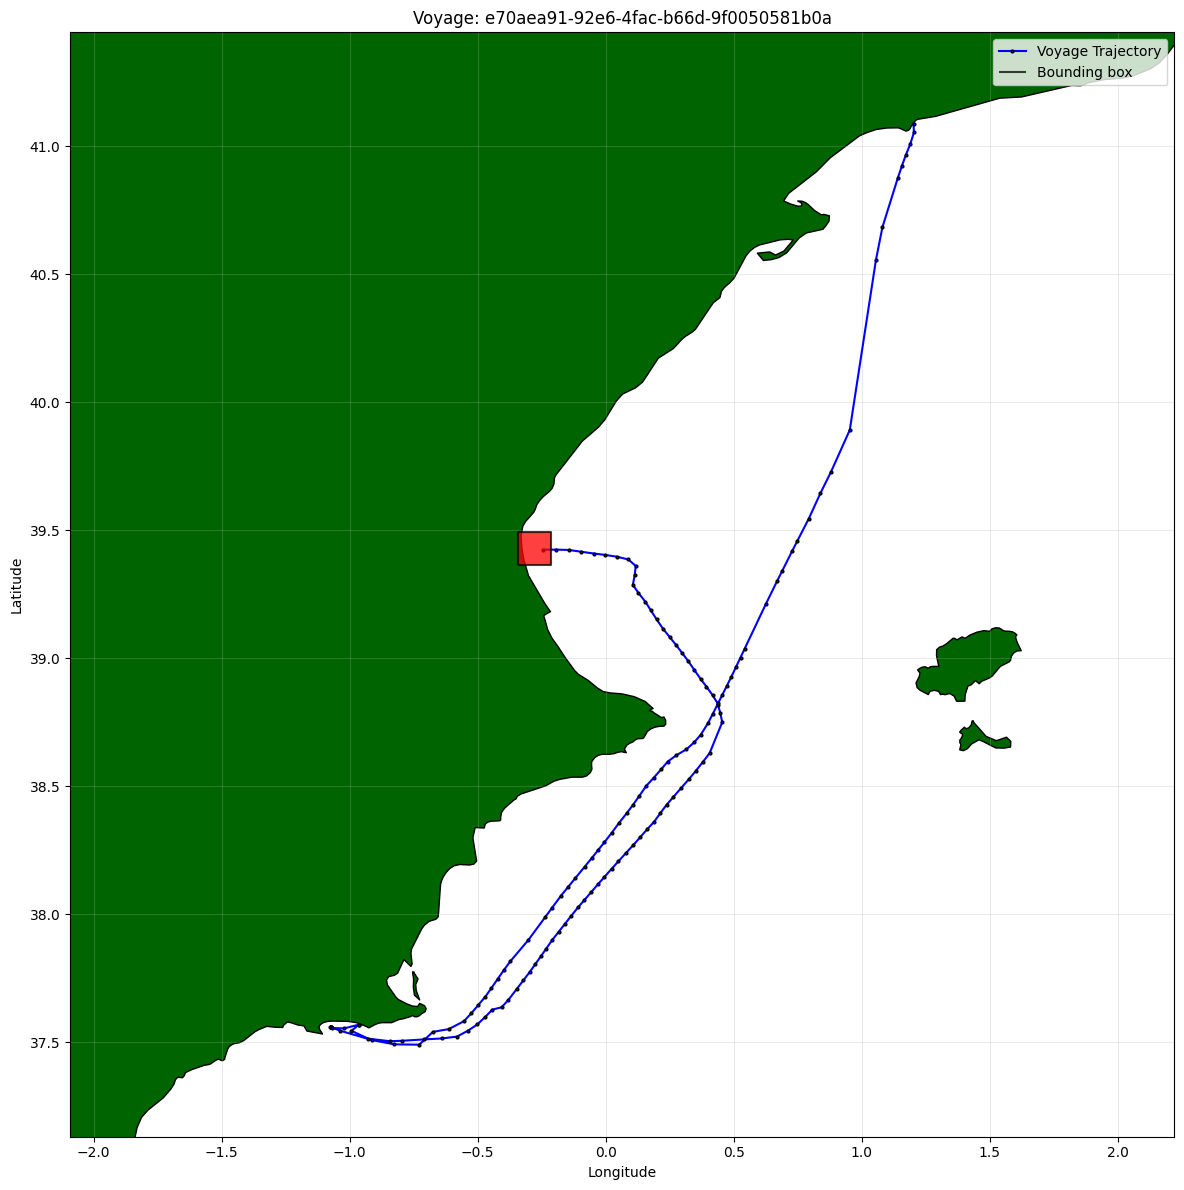

Voyage: e70aea91-92e6-4fac-b66d-9f0050581b0a 
Total traveled distance: 802.22 km
Duration: 195.93 hours
Data points: 142


In [951]:
sus_voyage_id2 = "e70aea91-92e6-4fac-b66d-9f0050581b0a"
sus_voyage_df2 = cargo_ais_meta_merged[cargo_ais_meta_merged["voyage_id"] == sus_voyage_id2]
plot_voyage_on_coastline(sus_voyage_df2, coastline, BBOX)

Worst OVERprediction:

/tmp/ipykernel_7014/569726036.py:43: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


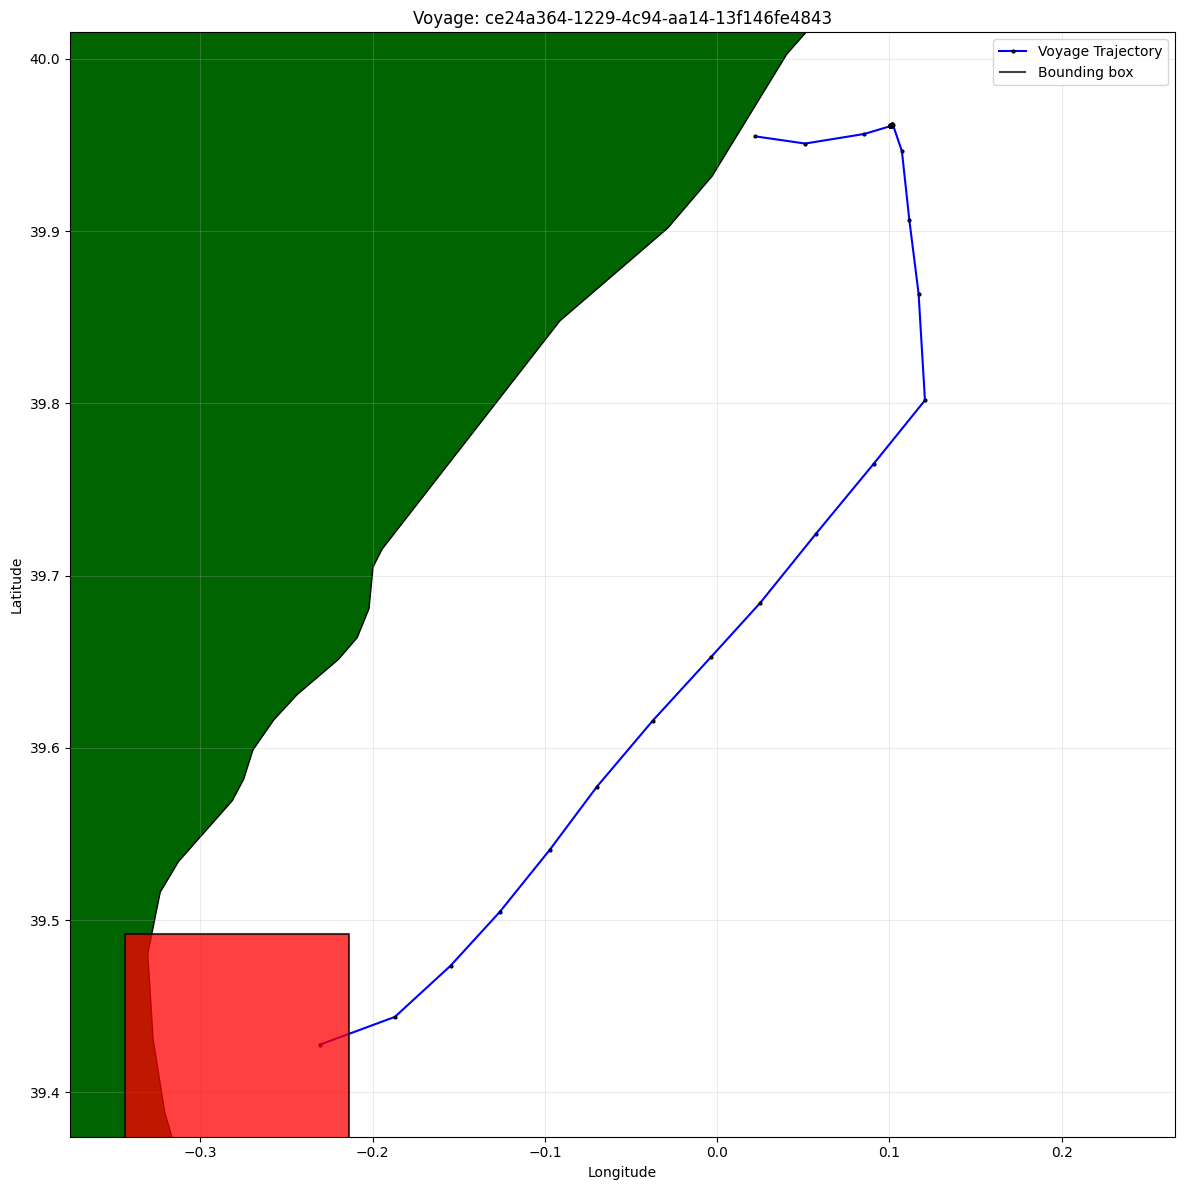

Voyage: ce24a364-1229-4c94-aa14-13f146fe4843 
Total traveled distance: 77.65 km
Duration: 35.13 hours
Data points: 95


In [952]:
sus_voyage_id = "ce24a364-1229-4c94-aa14-13f146fe4843"
sus_voyage_df = cargo_ais_meta_merged[cargo_ais_meta_merged["voyage_id"] == sus_voyage_id]
plot_voyage_on_coastline(sus_voyage_df, coastline, BBOX)

In [955]:
pct_24hr = np.mean(np.abs(errors) < 24) * 100
print(f"Within 24hr: {pct_24hr:.1f}%")

Within 24hr: 99.1%


In [ ]:
#import joblib
#joblib.dump(model_xgb, "xgb_0.joblib")

In [ ]:
#import joblib
#model = joblib.load("xgb_0.joblib")

#### Divide filtered data frame into remaining distance > 100, 50, 25 km

In [949]:
remaining_dist_100km_mask = cargo_ais_meta_merged["remaining_dist_live"] < 100
filtered_100km = cargo_ais_meta_merged[remaining_dist_100km_mask].copy()
filtered_100km.shape

(59316, 78)

Train model

In [ ]:
features = filtered_100km[feature_cols]
features.shape

In [ ]:
remaining_dist_50km_mask = cargo_ais_meta_merged["remaining_dist_km"] < 50
filtered_50km = cargo_ais_meta_merged[remaining_dist_50km_mask].copy()
filtered_50km.shape

In [ ]:
remaining_dist_25km_mask = cargo_ais_meta_merged["remaining_dist_km"] < 25
filtered_25km = cargo_ais_meta_merged[remaining_dist_25km_mask].copy()
filtered_25km.shape